# 9.2. Converting Raw Text into Sequence Data

Text preprocessing pipelines usally do
1. Load text as strings into memory.
2. Split the strings into tokens (e.g., words or characters).
3. Build a vocabulary dictionary to associate each vocabulary element with a numerical index.
4. Convert the text into sequences of numerical indices.


In [74]:
import re
import collections
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [75]:


def download_text(url: str) -> str:
    with urllib.request.urlopen(url) as response:
        total = int(response.headers.get('Content-Length', 0))
        chunk_size = 8192
        chunks = []
        downloaded = 0

        with tqdm(total=total, unit='B', unit_scale=True, desc='Downloading') as bar:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                chunks.append(chunk)
                downloaded += len(chunk)
                bar.update(len(chunk))
                if total:
                    bar.set_postfix(pct=f"{downloaded/total*100:.1f}%")

    return b''.join(chunks).decode('utf-8')


In [76]:
raw_text = download_text("https://www.gutenberg.org/files/35/35-0.txt")
print(raw_text[:50])


Downloading:   0%|          | 0.00/185k [00:00<?, ?B/s]

*** START OF THE PROJECT GUTENBERG EBOOK 35 ***



In [77]:

def preprocess(text):
    return re.sub('[^A-Za-z]+', ' ', text).lower()  

In [78]:
text = preprocess(raw_text)
text[:60]

' start of the project gutenberg ebook the time machine an in'

## Tokenization

In [79]:
def tokenize(text):
    return list(text)
tokens = tokenize(text)
print(tokens[:60])

[' ', 's', 't', 'a', 'r', 't', ' ', 'o', 'f', ' ', 't', 'h', 'e', ' ', 'p', 'r', 'o', 'j', 'e', 'c', 't', ' ', 'g', 'u', 't', 'e', 'n', 'b', 'e', 'r', 'g', ' ', 'e', 'b', 'o', 'o', 'k', ' ', 't', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'a', 'n', ' ', 'i', 'n']


## Vocabulary

In [80]:
class Vocab:
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq]),
            key=lambda x: str(x)))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):
        return self.token_to_idx['<unk>']

In [81]:
def create_corpus(raw_text, vocab=None):
    tokens = tokenize(preprocess(raw_text))
    if vocab is None: vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

In [82]:
corpus, vocab = create_corpus(raw_text, vocab=None)
len(corpus), len(vocab)

(174287, 28)

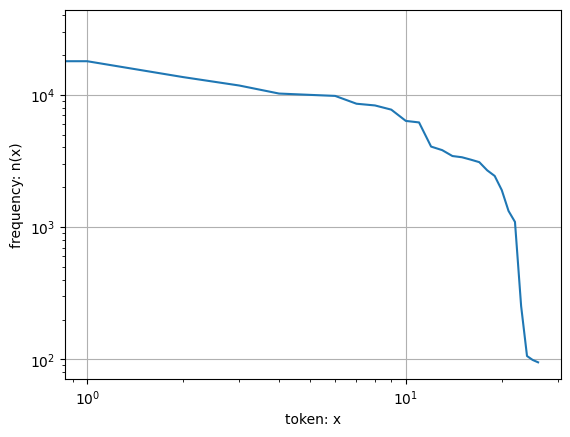

In [83]:
freqs = [freq for token, freq in vocab.token_freqs]
plt.plot(freqs)
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

## Biagram

In [84]:
bigrams = [pair for pair in zip(tokens[:-1], tokens[1:])]
bigram_vocab = Vocab(bigrams)

print('Most common bigrams:', bigram_vocab.token_freqs[:10])

Most common bigrams: [(('e', ' '), 6689), ((' ', 't'), 5612), (('t', 'h'), 4628), (('d', ' '), 4145), (('h', 'e'), 3889), ((' ', 'a'), 3868), (('t', ' '), 3567), (('s', ' '), 3192), ((' ', 'i'), 2987), (('i', 'n'), 2954)]


In [85]:
trigrams = [triple for triple in zip(tokens[:-2], tokens[1:-1], tokens[2:])]
trigram_vocab = Vocab(trigrams)

print('Most common trigrams:', trigram_vocab.token_freqs[:10])

Most common trigrams: [((' ', 't', 'h'), 3976), (('t', 'h', 'e'), 3151), (('h', 'e', ' '), 2458), (('n', 'd', ' '), 1613), ((' ', 'a', 'n'), 1468), (('e', 'd', ' '), 1454), (('a', 'n', 'd'), 1398), ((' ', 'i', ' '), 1268), ((' ', 'o', 'f'), 1198), (('o', 'f', ' '), 1168)]


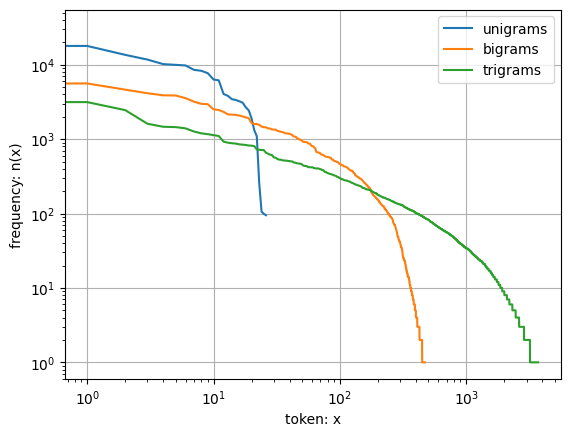

In [86]:
unigram_freqs = [freq for _, freq in vocab.token_freqs]
bigram_freqs  = [freq for _, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for _, freq in trigram_vocab.token_freqs]

plt.plot(unigram_freqs, label='unigrams')
plt.plot(bigram_freqs,  label='bigrams')
plt.plot(trigram_freqs, label='trigrams')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()